In [8]:
import os
import zipfile
import shutil
import random

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [10]:
zip_path = "plantvillage.zip"
extract_path = "plantvillage"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [11]:

def split_and_copy(source_dir, target_dirs, split_ratio):
    images = os.listdir(source_dir)
    random.shuffle(images)

    total = len(images)
    train_end = int(split_ratio[0] * total)
    val_end = train_end + int(split_ratio[1] * total)

    split_files = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, files in split_files.items():
        for file in files:
            src = os.path.join(source_dir, file)
            dst = os.path.join(target_dirs[split], file)
            shutil.copy(src, dst)

In [12]:

base_dir = "potato_dataset"
splits = ["train", "val", "test"]
classes = ["healthy", "diseased"]

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

print("All destination folders created successfully!")

All destination folders created successfully!


In [13]:
split_ratio = (0.7, 0.15, 0.15)

# Healthy
split_and_copy(
    source_dir="plantvillage/plantvillage/Potato___healthy",
    target_dirs={
        "train": "potato_dataset/train/healthy",
        "val": "potato_dataset/val/healthy",
        "test": "potato_dataset/test/healthy"
    },
    split_ratio=split_ratio
)

# Diseased (Early + Late blight)
for disease in ["Potato___Early_blight", "Potato___Late_blight"]:
    split_and_copy(
        source_dir=f"plantvillage/plantvillage/{disease}",
        target_dirs={
            "train": "potato_dataset/train/diseased",
            "val": "potato_dataset/val/diseased",
            "test": "potato_dataset/test/diseased"
        },
        split_ratio=split_ratio
    )

print("✅ Dataset split completed successfully!")

✅ Dataset split completed successfully!


In [14]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    "potato_dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_test_gen.flow_from_directory(
    "potato_dataset/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = val_test_gen.flow_from_directory(
    "potato_dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1506 images belonging to 2 classes.
Found 322 images belonging to 2 classes.
Found 324 images belonging to 2 classes.


In [15]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Freeze pretrained layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint("potato_disease_model.h5", save_best_only=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8646 - loss: 0.3802

48/48 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.9097 - loss: 0.2966 - val_accuracy: 0.9317 - val_loss: 0.2097
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9394 - loss: 0.1576

48/48 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9323 - loss: 0.1553 - val_accuracy: 0.9348 - val_loss: 0.1332
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9559 - loss: 0.1081

48/48 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9628 - loss: 0.1012 - val_accuracy: 0.9503 - val_loss: 0.0962
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9779 - loss: 0.0727

48/48 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9761 - loss: 0.0720 - val_accuracy: 0.9752 - val_loss: 0.0752
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9808 - loss: 0.0657

...

48/48 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.9894 - loss: 0.0352 - val_accuracy: 0.9907 - val_loss: 0.0381
Epoch 12/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9890 - loss: 0.0292

48/48 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.9907 - loss: 0.0299 - val_accuracy: 0.9907 - val_loss: 0.0365
Epoch 13/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9960 - loss: 0.0222

48/48 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9914 - loss: 0.0289 - val_accuracy: 0.9907 - val_loss: 0.0351
Epoch 14/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9940 - loss: 0.0223

48/48 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.9927 - loss: 0.0257 - val_accuracy: 0.9907 - val_loss: 0.0351
Epoch 15/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9949 - loss: 0.0217

48/48 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.9947 - loss: 0.0223 - val_accuracy: 0.9907 - val_loss: 0.0349


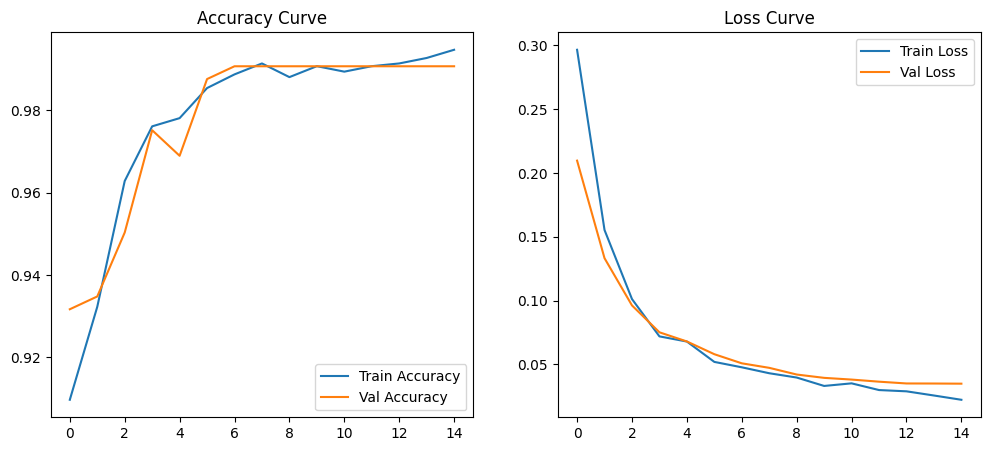

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.show()

In [11]:
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9846 - loss: 0.0434
Test Accuracy: 0.9846
Test Loss: 0.0434


In [12]:
import numpy as np

# Get true labels
y_true = test_data.classes

# Get predicted probabilities
y_pred_prob = model.predict(test_data)

# Convert probabilities to class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step


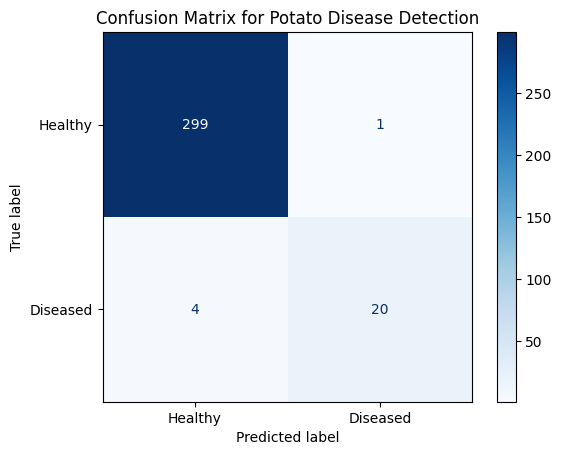

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "Diseased"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix for Potato Disease Detection")
plt.show()

In [14]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Healthy", "Diseased"]
    )
)

              precision    recall  f1-score   support

     Healthy       0.99      1.00      0.99       300
    Diseased       0.95      0.83      0.89        24

    accuracy                           0.98       324
   macro avg       0.97      0.92      0.94       324
weighted avg       0.98      0.98      0.98       324



In [15]:
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=["Healthy", "Diseased"],
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report.to_csv("potato_model_evaluation.csv")

print("Evaluation report saved!")

Evaluation report saved!


Selected image: potato_dataset/test/diseased/904dba96-8ff1-45e2-af16-9c9cc5865c32___RS_Early.B 7349.JPG


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


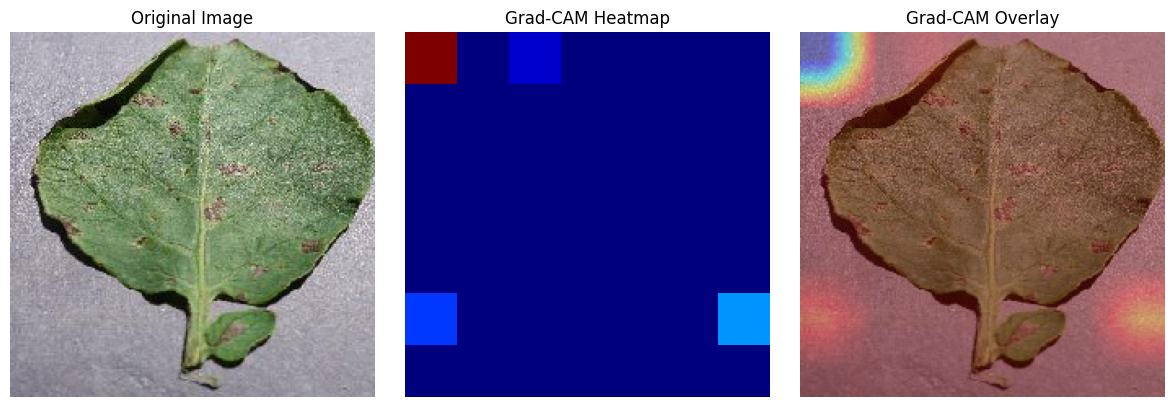

In [16]:
# =========================
# GRAD-CAM EXPLAINABILITY
# =========================

import os
import random
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# -------------------------
# STEP 1: CONFIGURATION
# -------------------------
IMG_SIZE = (224, 224)
LAST_CONV_LAYER = "out_relu"   # Correct for MobileNetV2

# -------------------------
# STEP 2: LOAD & PREPROCESS IMAGE
# -------------------------
def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, img

# -------------------------
# STEP 3: GRAD-CAM HEATMAP
# -------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]   # Binary classification

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()

# -------------------------
# STEP 4: OVERLAY HEATMAP
# -------------------------
def overlay_gradcam(original_img, heatmap, alpha=0.4):
    original_img = np.array(original_img)

    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlayed_img = cv2.addWeighted(original_img, 1 - alpha, heatmap, alpha, 0)
    return overlayed_img

# -------------------------
# STEP 5: AUTO-SELECT TEST IMAGE
# -------------------------
test_class = "diseased"  # change to "healthy" if needed
test_dir = f"potato_dataset/test/{test_class}"

img_name = random.choice(os.listdir(test_dir))
img_path = os.path.join(test_dir, img_name)

print("Selected image:", img_path)

# -------------------------
# STEP 6: RUN GRAD-CAM
# -------------------------
img_array, original_img = load_and_preprocess_image(img_path)

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    LAST_CONV_LAYER
)

gradcam_img = overlay_gradcam(original_img, heatmap)

# -------------------------
# STEP 7: DISPLAY RESULTS
# -------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gradcam_img)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

REVIEW - 2

In [18]:
# Check data generators

print("Train samples:", train_data.samples)
print("Validation samples:", val_data.samples)
print("Test samples:", test_data.samples)

print("Class indices:", train_data.class_indices)

Train samples: 1506
Validation samples: 322
Test samples: 324
Class indices: {'diseased': 0, 'healthy': 1}


In [17]:
# =====================================
# FINE-TUNING
# =====================================

# Unfreeze base model
base_model.trainable = True

# Freeze all layers except last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train again
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9748 - loss: 0.0877 - val_accuracy: 0.9752 - val_loss: 0.0838
Epoch 2/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9874 - loss: 0.0316 - val_accuracy: 0.9317 - val_loss: 1.0490
Epoch 3/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.9861 - loss: 0.0427 - val_accuracy: 0.9317 - val_loss: 3.2867
Epoch 4/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9920 - loss: 0.0264 - val_accuracy: 0.9317 - val_loss: 2.3994
Epoch 5/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9940 - loss: 0.0188 - val_accuracy: 0.9317 - val_loss: 2.0783


In [22]:
loss_resnet, acc_resnet = model_resnet.evaluate(test_data)
print("ResNet50 Test Accuracy:", acc_resnet)

11/11 ━━━━━━━━━━━━━━━━━━━━ 58s 5s/step - accuracy: 0.9259 - loss: 0.3559
ResNet50 Test Accuracy: 0.9259259104728699


In [23]:
loss_mob, acc_mob = model.evaluate(test_data)
print("MobileNet Test Accuracy:", acc_mob)

11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9259 - loss: 3.0468
MobileNet Test Accuracy: 0.9259259104728699


In [24]:
# =====================================
# REVIEW 2 - IMPROVEMENT 3: RESNET FINE-TUNING
# =====================================

# Unfreeze ResNet base model
base_model_resnet.trainable = True

# Freeze most layers, unfreeze last 30 layers
for layer in base_model_resnet.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate (VERY IMPORTANT)
from tensorflow.keras.optimizers import Adam

model_resnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train again
history_resnet_fine = model_resnet.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 454s 9s/step - accuracy: 0.9323 - loss: 0.2161 - val_accuracy: 0.9317 - val_loss: 0.2488
Epoch 2/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 435s 9s/step - accuracy: 0.9303 - loss: 0.2034 - val_accuracy: 0.9317 - val_loss: 0.2337
Epoch 3/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 435s 9s/step - accuracy: 0.9369 - loss: 0.1705 - val_accuracy: 0.9317 - val_loss: 0.2949
Epoch 4/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 437s 9s/step - accuracy: 0.9402 - loss: 0.1780 - val_accuracy: 0.9317 - val_loss: 0.6695
Epoch 5/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 439s 9s/step - accuracy: 0.9416 - loss: 0.1505 - val_accuracy: 0.9317 - val_loss: 0.4120


In [25]:
loss_resnet_fine, acc_resnet_fine = model_resnet.evaluate(test_data)
print("ResNet Fine-Tuned Accuracy:", acc_resnet_fine)

11/11 ━━━━━━━━━━━━━━━━━━━━ 57s 5s/step - accuracy: 0.9259 - loss: 0.5918
ResNet Fine-Tuned Accuracy: 0.9259259104728699


In [26]:
# =====================================
# REVIEW 2 - CONFUSION MATRIX
# =====================================

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predictions (use your main model - MobileNet)
preds = model.predict(test_data)
y_pred = (preds > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(test_data.classes, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(test_data.classes, y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step
Confusion Matrix:
 [[300   0]
 [ 24   0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.93      1.00      0.96       300
           1       0.00      0.00      0.00        24

    accuracy                           0.93       324
   macro avg       0.46      0.50      0.48       324
weighted avg       0.86      0.93      0.89       324



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step


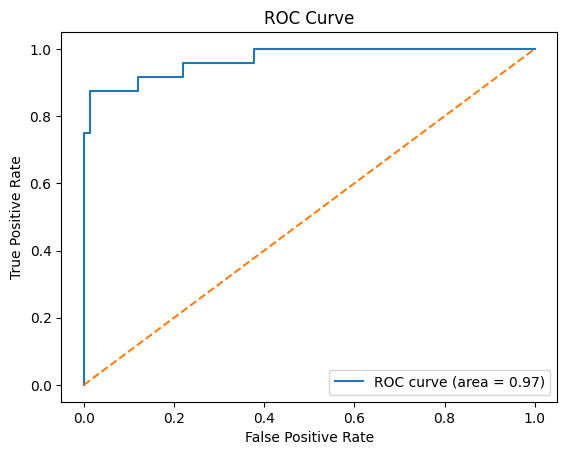

AUC Score: 0.9684722222222222


In [27]:
# =====================================
# REVIEW 2 - ROC CURVE & AUC
# =====================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get prediction probabilities
preds = model.predict(test_data)

# Calculate ROC
fpr, tpr, thresholds = roc_curve(test_data.classes, preds)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

print("AUC Score:", roc_auc)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


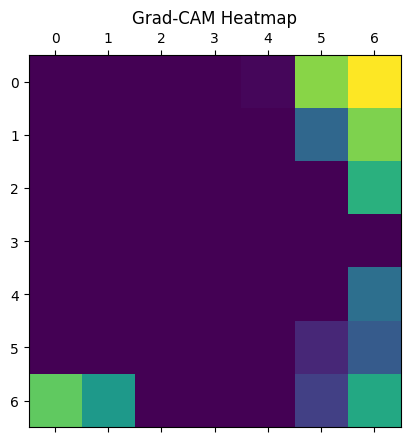

In [28]:
# =====================================
# REVIEW 2 - GRAD-CAM VISUALIZATION
# =====================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Get last convolution layer name (MobileNetV2)
last_conv_layer_name = "Conv_1"

# Function to generate Grad-CAM heatmap
def get_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Load one test image
img_path = test_data.filepaths[0]

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Generate heatmap
heatmap = get_gradcam_heatmap(img_array, model, last_conv_layer_name)

# Display
plt.matshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.show()

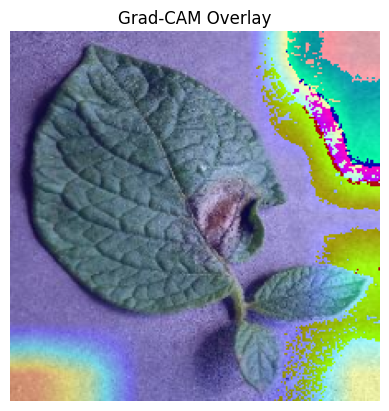

In [29]:
# =====================================
# OVERLAY HEATMAP ON IMAGE
# =====================================

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Grad-CAM Overlay")
plt.show()